# Homework
### Silvia Parente
#### due April 24th

a) Select galaxies and quasars with redshifts between 0.05 and 0.3 and signal-to-noise ratios greater than 35 near
the Hβ line. Ensure that lines [O III] λ5007, Hβ λ4863, and Hγ λ4341 are present in emission and that the FWHM of
Hβ is greater than 1000 km/s. For each selected spectrum, find the flux ratios of [O III]/Hβ, Hβ/Hγ, and [O III]/Hγ,
as well as the equivalent width and flux of Hβ, redshift, and extinction correction: E(B-V) of type SFD (tip: the last
one find in galSpecInfo table).


In [1]:
'''
SELECT 
    s.plate, s.mjd, s.fiberid, s.z,
    (g.oiii_5007_flux / g.h_beta_flux) AS ratio_oiii_hb,
    (g.h_beta_flux / g.h_gamma_flux) AS ratio_hb_hg,
    (g.oiii_5007_flux / g.h_gamma_flux) AS ratio_oiii_hg,
    g.h_beta_eqw, 
    g.h_beta_flux, 
    i.e_bv_sfd
FROM SpecObj AS s
JOIN GalSpecLine AS g ON s.specobjid = g.specobjid
JOIN GalSpecInfo AS i ON s.specobjid = i.specobjid
WHERE 
    (s.class = 'QSO' OR s.class = 'GALAXY') 
    AND s.z BETWEEN 0.05 AND 0.3
    AND s.snmedian_g > 35
    AND g.oiii_5007_eqw < -1
    AND g.h_beta_eqw < -1
    AND g.h_gamma_eqw < -1
    AND g.sigma_balmer > 424.6
    -- encountered a division by zero error
    AND g.h_beta_flux > 0
    AND g.h_gamma_flux > 0
'''

"\nSELECT \n    s.plate, s.mjd, s.fiberid, s.z,\n    (g.oiii_5007_flux / g.h_beta_flux) AS ratio_oiii_hb,\n    (g.h_beta_flux / g.h_gamma_flux) AS ratio_hb_hg,\n    (g.oiii_5007_flux / g.h_gamma_flux) AS ratio_oiii_hg,\n    g.h_beta_eqw, \n    g.h_beta_flux, \n    i.e_bv_sfd\nFROM SpecObj AS s\nJOIN GalSpecLine AS g ON s.specobjid = g.specobjid\nJOIN GalSpecInfo AS i ON s.specobjid = i.specobjid\nWHERE \n    (s.class = 'QSO' OR s.class = 'GALAXY') \n    AND s.z BETWEEN 0.05 AND 0.3\n    AND s.snmedian_g > 35\n    AND g.oiii_5007_eqw < -1\n    AND g.h_beta_eqw < -1\n    AND g.h_gamma_eqw < -1\n    AND g.sigma_balmer > 424.6\n    -- encountered a division by zero error\n    AND g.h_beta_flux > 0\n    AND g.h_gamma_flux > 0\n"

In [2]:
import pandas as pd

pd.read_csv('ex1.csv')


,,,,,,,,,#Table1
plate,mjd,fiberid,z,ratio_oiii_hb,ratio_hb_hg,ratio_oiii_hg,h_beta_eqw,h_beta_flux,e_bv_sfd
1059,52618,628,0.06183716,0.9926052,1.898506,1.884467,-12.15111,1786.943,0.04036992
572,52289,442,0.1617697,0.336162,2.26272,0.7606404,-16.94715,1354.625,0.03441319
2773,54533,640,0.2134592,0.2488954,1.947451,0.4847117,-14.82997,1652.594,0.03172268
355,51788,414,0.09262062,0.7112553,2.642485,1.879482,-10.94744,1590.3,0.04385718
...,...,...,...,...,...,...,...,...,...
624,52377,629,0.2622212,0.693274,2.52641,1.751494,-22.66697,1245.307,0.01507206
2533,54585,612,0.1472984,0.6300117,1.699741,1.070857,-8.637259,873.853,0.05242494
1218,52709,54,0.05502596,0.3048607,2.144933,0.6539056,-23.61081,3987.076,0.01521724
2649,54212,215,0.1266571,1.036598,1.842654,1.910092,-8.841555,2140.768,0.05069542


b) How many objects have you found? Which one from the conditions in WHERE is narrowing the results most
severely?

To count how many objects i found:

In [3]:
'''
SELECT s.class, count(*)
FROM SpecObj AS s
JOIN GalSpecLine AS g ON s.specobjid = g.specobjid
JOIN GalSpecInfo AS i ON s.specobjid = i.specobjid
WHERE 
    (s.class = 'QSO' OR s.class = 'GALAXY') 
    AND s.z BETWEEN 0.05 AND 0.3
    AND s.snmedian_g > 35
    AND g.oiii_5007_eqw < -1
    AND g.h_beta_eqw < -1
    AND g.h_gamma_eqw < -1
    AND g.sigma_balmer > 424.6
    AND g.h_beta_flux > 0
    AND g.h_gamma_flux > 0
GROUP BY s.class
'''

"\nSELECT s.class, count(*)\nFROM SpecObj AS s\nJOIN GalSpecLine AS g ON s.specobjid = g.specobjid\nJOIN GalSpecInfo AS i ON s.specobjid = i.specobjid\nWHERE \n    (s.class = 'QSO' OR s.class = 'GALAXY') \n    AND s.z BETWEEN 0.05 AND 0.3\n    AND s.snmedian_g > 35\n    AND g.oiii_5007_eqw < -1\n    AND g.h_beta_eqw < -1\n    AND g.h_gamma_eqw < -1\n    AND g.sigma_balmer > 424.6\n    AND g.h_beta_flux > 0\n    AND g.h_gamma_flux > 0\nGROUP BY s.class\n"

In [4]:
pd.read_csv('ex2_1.csv')

,#Table1
class,Column1
QSO,153


The most severe condition is snmedian_g > 35. 
If I remove the S/N > 35 limit, the results is:

In [5]:
pd.read_csv('ex2_2.csv')

,#Table1
class,Column1
GALAXY,173
QSO,5340


c) Find out if there is some of the Subclass AGN objects, with the same conditions under a). Adopt your code to get result.

In [6]:
'''
SELECT s.class, s.subclass, count(*)
FROM SpecObj AS s
JOIN GalSpecLine AS g ON s.specobjid = g.specobjid
JOIN GalSpecInfo AS i ON s.specobjid = i.specobjid
WHERE 
    (s.class = 'QSO' OR s.class = 'GALAXY') 
    AND s.z BETWEEN 0.05 AND 0.3
    AND s.snmedian_g > 35
    AND g.oiii_5007_eqw < -1
    AND g.h_beta_eqw < -1
    AND g.h_gamma_eqw < -1
    AND g.sigma_balmer > 424.6
    AND g.h_beta_flux > 0
    AND g.h_gamma_flux > 0
GROUP BY s.class, s.subclass
'''

pd.read_csv('ex3.csv')

#Table1
class subclass             Column1
QSO   STARBURST BROADLINE       76
      BROADLINE                 67
      AGN BROADLINE             10

d) Modify your solution under a) to include objects with redshift between 0.05 and 0.6. Using this modified solution and the list of objects (287-plate-mjd-fiber.txt) submit the SQL query via CrossID. 

In [7]:
''' 
CREATE TABLE #upload ( up_id int, up_plate int, up_mjd int, up_fiber int ) 
INSERT INTO #upload values ( 1, 423, 51821, 295),( 2, 1949, 53433, 472),( 3, 1273, 52993, 348),( 4, 2030, 53499, 201),( 5, 2520, 54584, 442),( 6, 1940, 53383, 407),( 7, 561, 52295, 618),( 8, 1603, 53119, 558),( 9, 453, 51915, 212),( 10, 1427, 52996, 606),( 11, 464, 51908, 576),( 12, 634, 52164, 430),( 13, 2020, 53431, 614),( 14, 2007, 53474, 171),( 15, 916, 52378, 434),( 16, 603, 52056, 415),( 17, 2089, 53498, 385),( 18, 625, 52145, 288),( 19, 436, 51883, 16),( 20, 999, 52636, 334),( 21, 1683, 53436, 16),( 22, 2425, 54139, 442),( 23, 433, 51873, 422),( 24, 465, 51910, 603),( 25, 513, 51989, 340),( 26, 366, 52017, 584),( 27, 329, 52056, 577),( 28, 564, 52224, 368),( 29, 564, 52224, 471),( 30, 753, 52233, 455),( 31, 755, 52235, 225),( 32, 1052, 52466, 370),( 33, 738, 52521, 95),( 34, 993, 52710, 147),( 35, 914, 52721, 74),( 36, 1351, 52790, 428),( 37, 1342, 52793, 157),( 38, 1864, 53313, 353),( 39, 2491, 53855, 252),( 40, 848, 52669, 418),( 41, 555, 52266, 74),( 42, 1371, 52821, 377),( 43, 1844, 54138, 112),( 44, 1417, 53141, 441),( 45, 2783, 54524, 432),( 46, 2641, 54230, 570),( 47, 490, 51929, 126),( 48, 1796, 53884, 591),( 49, 2509, 54180, 244),( 50, 2647, 54495, 160),( 51, 2488, 54149, 521),( 52, 1186, 52646, 98),( 53, 2164, 53886, 503),( 54, 640, 52178, 513),( 55, 2646, 54479, 204),( 56, 2583, 54095, 615),( 57, 2501, 54084, 120),( 58, 2128, 53800, 415),( 59, 2518, 54243, 374),( 60, 413, 51929, 598),( 61, 837, 52642, 298),( 62, 2645, 54477, 133),( 63, 2353, 53794, 600),( 64, 1843, 53816, 584),( 65, 2970, 54589, 373),( 66, 967, 52636, 44),( 67, 767, 52252, 300),( 68, 593, 52026, 111),( 69, 984, 52442, 383),( 70, 1429, 52990, 584),( 71, 2769, 54527, 354),( 72, 2532, 54589, 90),( 73, 2166, 54232, 30),( 74, 2281, 53711, 431),( 75, 2420, 54086, 240),( 76, 597, 52059, 337),( 77, 1598, 53033, 291),( 78, 1237, 52762, 497),( 79, 593, 52026, 170),( 80, 656, 52148, 282),( 81, 461, 51910, 74),( 82, 1750, 53358, 564),( 83, 764, 52238, 53),( 84, 2512, 53877, 582),( 85, 469, 51913, 238),( 86, 892, 52378, 395),( 87, 268, 51633, 235),( 88, 1793, 53883, 573),( 89, 1598, 53033, 604),( 90, 2595, 54207, 541),( 91, 1817, 53851, 69),( 92, 349, 51699, 613),( 93, 2440, 53818, 539),( 94, 1713, 53827, 63),( 95, 567, 52252, 558),( 96, 1690, 53475, 634),( 97, 385, 51877, 61),( 98, 2351, 53772, 99),( 99, 1230, 52672, 503),( 100, 1431, 52992, 572),( 101, 2971, 54590, 326),( 102, 1575, 53493, 484),( 103, 2764, 54535, 53),( 104, 1773, 53112, 301),( 105, 498, 51984, 104),( 106, 411, 51817, 381),( 107, 2034, 53466, 230),( 108, 637, 52174, 259),( 109, 2529, 54585, 300),( 110, 600, 52317, 490),( 111, 1223, 52781, 625),( 112, 551, 51993, 179),( 113, 2478, 54097, 377),( 114, 721, 52228, 454),( 115, 1676, 53147, 55),( 116, 1626, 53472, 449),( 117, 614, 53437, 452),( 118, 1754, 53385, 324),( 119, 2364, 53737, 469),( 120, 2606, 54154, 614),( 121, 1775, 53847, 420),( 122, 1791, 54266, 46),( 123, 2080, 53350, 309),( 124, 2294, 53733, 607),( 125, 1838, 53467, 451),( 126, 2351, 53772, 616),( 127, 1167, 52738, 476),( 128, 1695, 53473, 612),( 129, 1989, 53772, 559),( 130, 1667, 53430, 114),( 131, 2885, 54497, 561),( 132, 2008, 53473, 615),( 133, 2347, 53757, 326),( 134, 2341, 53738, 66),( 135, 1378, 53061, 413),( 136, 1949, 53433, 437),( 137, 1779, 53089, 106),( 138, 1201, 52674, 225),( 139, 752, 52251, 20),( 140, 511, 52636, 567),( 141, 2424, 54448, 109),( 142, 1428, 52998, 558),( 143, 2101, 53858, 348),( 144, 666, 52149, 24),( 145, 628, 52083, 461),( 146, 793, 52370, 549),( 147, 1714, 53521, 11),( 148, 1872, 53386, 371),( 149, 1725, 54266, 540),( 150, 1944, 53385, 412),( 151, 2522, 54570, 131),( 152, 664, 52174, 455),( 153, 939, 52636, 172),( 154, 2347, 53757, 151),( 155, 836, 52376, 262),( 156, 1329, 52767, 542),( 157, 773, 52376, 629),( 158, 1433, 53035, 148),( 159, 2376, 53770, 497),( 160, 2592, 54178, 153),( 161, 1455, 53089, 584),( 162, 899, 52620, 626),( 163, 723, 52201, 500),( 164, 896, 52592, 63),( 165, 597, 52059, 520),( 166, 554, 52000, 553),( 167, 1453, 53084, 10),( 168, 1865, 53312, 572),( 169, 942, 52703, 488),( 170, 897, 52605, 242),( 171, 2222, 53799, 388),( 172, 1847, 54176, 630),( 173, 1807, 54175, 9),( 174, 1364, 53061, 185),( 175, 795, 52378, 381),( 176, 2517, 54567, 624),( 177, 1372, 53062, 488),( 178, 1367, 53083, 629),( 179, 1773, 53112, 405),( 180, 2583, 54095, 462),( 181, 932, 52620, 110),( 182, 2237, 53828, 93),( 183, 1604, 53078, 281),( 184, 2173, 53874, 354),( 185, 408, 51821, 611),( 186, 768, 52281, 85),( 187, 1694, 53472, 540),( 188, 1394, 53108, 44),( 189, 411, 51817, 519),( 190, 1941, 53386, 545),( 191, 653, 52145, 185),( 192, 2106, 53714, 130),( 193, 994, 52725, 86),( 194, 2152, 53874, 108),( 195, 1714, 53521, 571),( 196, 1378, 53061, 488),( 197, 1606, 53055, 166),( 198, 1195, 52724, 98),( 199, 1854, 53566, 151),( 200, 2772, 54529, 38),( 201, 650, 52143, 126),( 202, 1843, 53816, 8),( 203, 1619, 53084, 60),( 204, 722, 52224, 281),( 205, 2023, 53851, 65),( 206, 526, 52312, 378),( 207, 2003, 53442, 501),( 208, 510, 52381, 509),( 209, 2365, 53739, 591),( 210, 2617, 54502, 287),( 211, 666, 52149, 496),( 212, 2526, 54582, 404),( 213, 409, 51871, 213),( 214, 1803, 54152, 323),( 215, 1795, 54507, 509),( 216, 2362, 53759, 295),( 217, 1926, 53317, 378),( 218, 860, 52319, 583),( 219, 2216, 53795, 298),( 220, 1810, 53794, 504),( 221, 2508, 53875, 353),( 222, 1744, 53055, 387),( 223, 1271, 52974, 462),( 224, 1214, 52731, 160),( 225, 2493, 54115, 278),( 226, 1735, 53035, 322),( 227, 1218, 52709, 201),( 228, 1457, 53116, 421),( 229, 607, 52368, 581),( 230, 767, 52252, 453),( 231, 2102, 54115, 18),( 232, 2352, 53770, 242),( 233, 507, 52353, 161),( 234, 2613, 54481, 620),( 235, 976, 52413, 574),( 236, 814, 52443, 467),( 237, 2265, 53674, 87),( 238, 1645, 53172, 526),( 239, 2615, 54483, 404),( 240, 987, 52523, 157),( 241, 792, 52353, 116),( 242, 2744, 54272, 535),( 243, 1728, 53228, 218),( 244, 1716, 53827, 350),( 245, 2007, 53474, 226),( 246, 827, 52312, 621),( 247, 882, 52370, 376),( 248, 1199, 52703, 596),( 249, 1402, 52872, 594),( 250, 1446, 53080, 135),( 251, 2615, 54483, 257),( 252, 594, 52045, 73),( 253, 2276, 53712, 508),( 254, 1845, 54144, 637),( 255, 1362, 53050, 119),( 256, 596, 52370, 483),( 257, 2151, 54523, 527),( 258, 1215, 52725, 150),( 259, 1224, 52765, 379),( 260, 1843, 53816, 502),( 261, 856, 52339, 50),( 262, 1440, 53084, 137),( 263, 941, 52709, 616),( 264, 2233, 53845, 196),( 265, 1592, 52990, 18),( 266, 2795, 54563, 140),( 267, 2428, 53801, 356),( 268, 489, 51930, 402),( 269, 795, 52378, 528),( 270, 1214, 52731, 77),( 271, 1005, 52703, 518),( 272, 402, 51793, 479),( 273, 2242, 54153, 199),( 274, 1004, 52723, 280),( 275, 1310, 53033, 559),( 276, 1380, 53084, 58),( 277, 1054, 52516, 309),( 278, 2492, 54178, 562),( 279, 2955, 54562, 608),( 280, 353, 51703, 546),( 281, 644, 52173, 413),( 282, 1432, 53003, 91),( 283, 741, 52261, 116),( 284, 1171, 52753, 416),( 285, 2774, 54534, 51),( 286, 2485, 54176, 231),( 287, 2292, 53713, 348)
SELECT 
    s.plate, s.mjd, s.fiberid, s.z,
    (g.oiii_5007_flux / g.h_beta_flux) AS ratio_oiii_hb,
    (g.h_beta_flux / g.h_gamma_flux) AS ratio_hb_hg,
    (g.oiii_5007_flux / g.h_gamma_flux) AS ratio_oiii_hg,
    g.h_beta_eqw, 
    g.h_beta_flux, 
    i.e_bv_sfd
FROM SpecObj AS s
JOIN GalSpecLine AS g ON s.specobjid = g.specobjid
JOIN GalSpecInfo AS i ON s.specobjid = i.specobjid
WHERE 
     s.z BETWEEN 0.05 AND 0.6
    AND s.snmedian_g > 35
    AND g.oiii_5007_eqw < -1
    AND g.h_beta_eqw < -1
    AND g.h_gamma_eqw < -1
    AND g.sigma_balmer > 424.6
    -- encountered a division by zero error
    AND g.h_beta_flux > 0
    AND g.h_gamma_flux > 0
'''

' \nCREATE TABLE #upload ( up_id int, up_plate int, up_mjd int, up_fiber int ) \nINSERT INTO #upload values ( 1, 423, 51821, 295),( 2, 1949, 53433, 472),( 3, 1273, 52993, 348),( 4, 2030, 53499, 201),( 5, 2520, 54584, 442),( 6, 1940, 53383, 407),( 7, 561, 52295, 618),( 8, 1603, 53119, 558),( 9, 453, 51915, 212),( 10, 1427, 52996, 606),( 11, 464, 51908, 576),( 12, 634, 52164, 430),( 13, 2020, 53431, 614),( 14, 2007, 53474, 171),( 15, 916, 52378, 434),( 16, 603, 52056, 415),( 17, 2089, 53498, 385),( 18, 625, 52145, 288),( 19, 436, 51883, 16),( 20, 999, 52636, 334),( 21, 1683, 53436, 16),( 22, 2425, 54139, 442),( 23, 433, 51873, 422),( 24, 465, 51910, 603),( 25, 513, 51989, 340),( 26, 366, 52017, 584),( 27, 329, 52056, 577),( 28, 564, 52224, 368),( 29, 564, 52224, 471),( 30, 753, 52233, 455),( 31, 755, 52235, 225),( 32, 1052, 52466, 370),( 33, 738, 52521, 95),( 34, 993, 52710, 147),( 35, 914, 52721, 74),( 36, 1351, 52790, 428),( 37, 1342, 52793, 157),( 38, 1864, 53313, 353),( 39, 2491, 538

In [8]:
pd.read_csv('ex4.csv')

,,,,,,,,,#Table1
plate,mjd,fiberid,z,ratio_oiii_hb,ratio_hb_hg,ratio_oiii_hg,h_beta_eqw,h_beta_flux,e_bv_sfd
353,51703,377,0.3715231,2.395043,1.132355,2.712039,-5.188211,1577.36,0.02278602
706,52199,177,0.261786,0.432131,1.988973,0.8594971,-11.99727,3686.314,0.02895055
1433,53035,134,0.3902647,0.207979,1.787916,0.371849,-11.02085,1103.879,0.01115778
1575,53493,495,0.2688824,0.1576048,2.475892,0.3902123,-17.37642,1758.446,0.05115553
...,...,...,...,...,...,...,...,...,...
278,51900,527,0.09478367,0.4972242,1.955276,0.9722104,-11.29103,1421.419,0.03967275
495,51988,207,0.2817113,0.4739082,2.320319,1.099618,-20.40405,1639.537,0.02384331
564,52224,322,0.060387,0.7621899,2.16548,1.650507,-21.58853,1887.681,0.03116452
1873,54437,413,0.3679648,0.5206459,2.377883,1.238035,-11.63341,1955.585,0.07418384


e) Check the spectra of found objects, download some of them using wget.

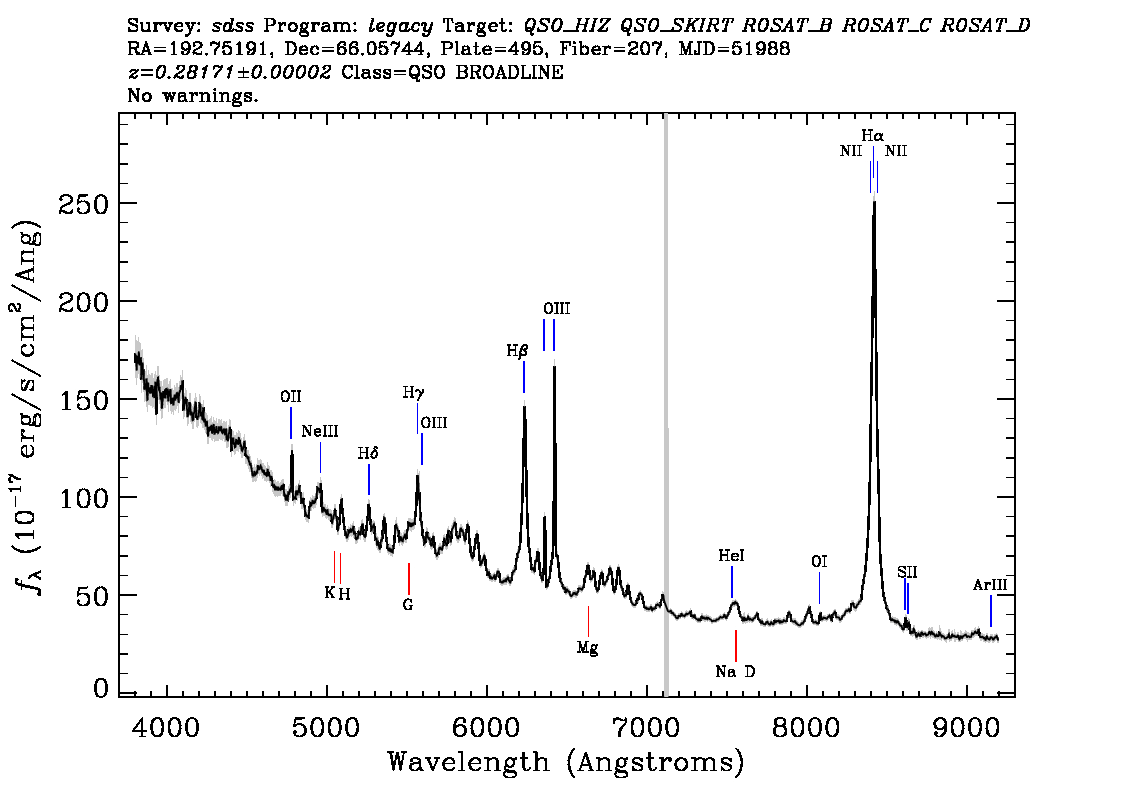

In [9]:
# Plate 495/51988, fiber 207	

from IPython.display import Image
Image(filename='495.51988.207.jpeg') 

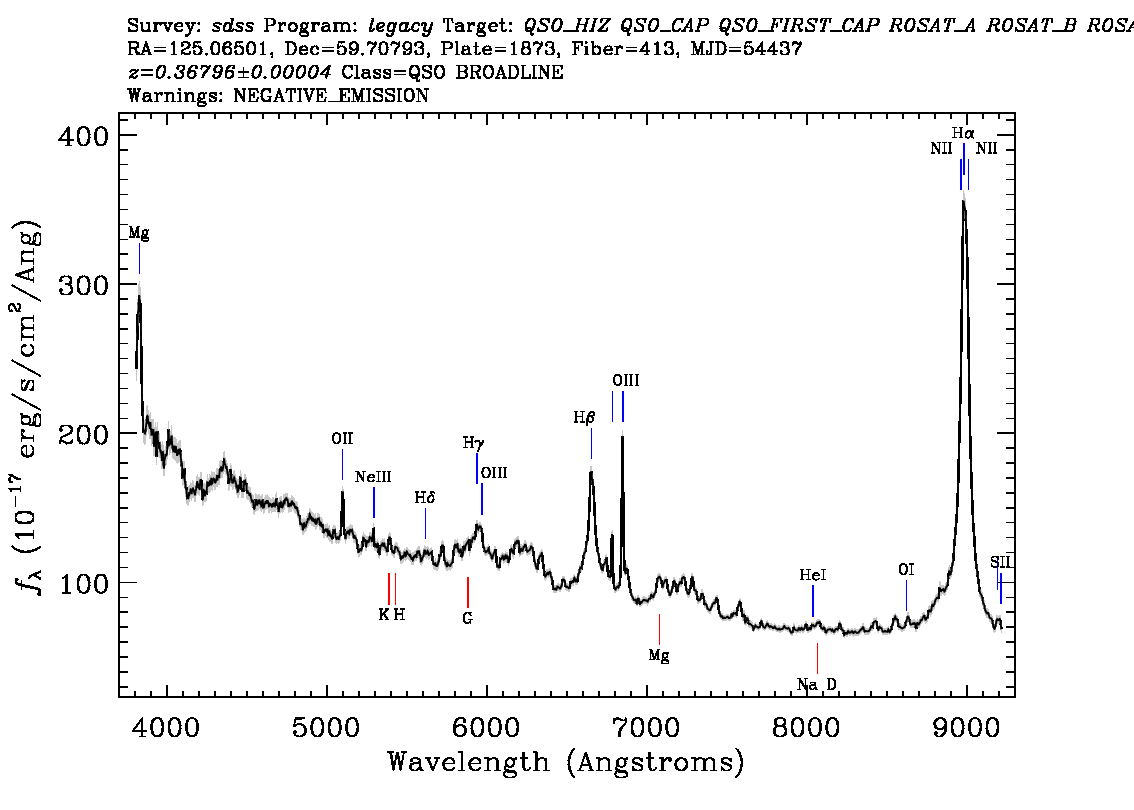

In [10]:
# Plate 1873/54437, fiber 413	

from IPython.display import Image
Image(filename='1873.54437.413.jpeg') 